# Student information
*   **Student ID:** 20521446
*   **Full name:** Huynh Nguyen Van Khanh



# Get libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                            precision_recall_fscore_support,
                            f1_score, recall_score,
                            precision_score,
                            confusion_matrix,
                            ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import scipy.stats as stats
import re
import seaborn as sns

#Load processed data

## Connect Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
%cd /content/drive/MyDrive/[CS116] Lập trình Python cho ML/

/content/drive/MyDrive/[CS116] Lập trình Python cho ML


## Load data and seperate features, target

In [ ]:
df = pd.read_csv("./Files/cleaned_credit_score.csv")
X = df.loc[:, df.columns != 'Credit_Score'].to_numpy()
y = df['Credit_Score'].to_numpy()

# Training model

## Tuning with RandomSearchCV

In [ ]:
print("X shape: ",X.shape)
print("y shape: "y.,shape)

X shape:  (100000, 33)
y shape:  (100000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2)

rf = RandomForestClassifier()
params = {'criterion' : ['gini', 'entropy', 'log_loss'],
          'max_features': ['sqrt', 'log2', None],
          'n_estimators': [10, 40, 100, 150],
          'max_depth': [2, 5, 10, 20, 40, 50]
          }
clf = RandomizedSearchCV(rf, params, n_iter=50 , verbose=3)
search = clf.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END criterion=entropy, max_depth=5, max_features=sqrt, n_estimators=150;, score=0.668 total time=  22.4s
[CV 2/5] END criterion=entropy, max_depth=5, max_features=sqrt, n_estimators=150;, score=0.664 total time=  13.6s
[CV 3/5] END criterion=entropy, max_depth=5, max_features=sqrt, n_estimators=150;, score=0.655 total time=  12.9s
[CV 4/5] END criterion=entropy, max_depth=5, max_features=sqrt, n_estimators=150;, score=0.666 total time=  13.1s
[CV 5/5] END criterion=entropy, max_depth=5, max_features=sqrt, n_estimators=150;, score=0.663 total time=  13.2s
[CV 1/5] END criterion=log_loss, max_depth=50, max_features=sqrt, n_estimators=40;, score=0.817 total time=  11.0s
[CV 2/5] END criterion=log_loss, max_depth=50, max_features=sqrt, n_estimators=40;, score=0.816 total time=  11.6s
[CV 3/5] END criterion=log_loss, max_depth=50, max_features=sqrt, n_estimators=40;, score=0.814 total time=  11.6s
[CV 4/5] END criterion=

## Save RandomSearchCV results

In [ ]:
# convert array into dataframe
cv_results = pd.DataFrame(search.cv_results_)

# save the dataframe as a csv file
cv_results.to_csv("./Files/RandomSearch_CV_RandomForest.csv")


## Top 5 best model after RandomSearchCV

In [ ]:
cv_results = pd.read_csv("./Files/RandomSearch_CV_RandomForest.csv")

In [ ]:
cv_results.sort_values(by=['rank_test_score']).head(5)[['param_criterion',
                                                        'param_max_features',
                                                        'param_max_depth',
                                                        'param_n_estimators',
                                                        'mean_test_score']]

,param_criterion,param_max_features,param_max_depth,param_n_estimators,mean_test_score
21,gini,sqrt,50,150,0.822850
10,gini,log2,40,150,0.822075
37,gini,log2,50,150,0.821462
34,entropy,log2,50,100,0.821313
22,gini,sqrt,40,100,0.820063


## Best model's parameters

In [ ]:
search.best_params_

{'n_estimators': 150,
 'max_features': 'sqrt',
 'max_depth': 50,
 'criterion': 'gini'}

In [ ]:
print(f"Best score after RandomSearchCV: {search.best_score_}")

Best score after RandomSearchCV: 0.8228499999999999


# Evaluate

## Compare tuned model and sklearn default model

In [ ]:
print("X shape: ",X.shape)
print("y shape: ",y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2)

clf = RandomForestClassifier(max_depth=50, n_estimators=150, criterion='gini', max_features='sqrt', random_state=0)
clf_default = RandomForestClassifier(random_state=0)

clf.fit(X_train, y_train)
clf_default.fit(X_train, y_train)

print("Accuracy test on tuned model: ", clf.score(X_test, y_test))
print("Accuracy test on default model: ", clf_default.score(X_test, y_test))

X shape:  (100000, 33)
y shape:  (100000,)
Accuracy test on tuned model:  0.82825
Accuracy test on default model:  0.8283


In [ ]:
target_names = ['Good', 'Poor', 'Standard']

y_pred = clf_default.predict(X_test)
print(" " * 24, end="")
print("DEFAULT MODEL")
print(classification_report(y_test, y_pred, target_names=target_names))
print(f"F1 {f1_score(y_pred, y_test, average='macro')}")
print(f"Recall {recall_score(y_pred, y_test, average='macro')}")
print(f"Precision {precision_score(y_pred, y_test, average='macro')}")

print("=" * 50, end='\n\n')

y_pred = clf.predict(X_test)
print(" " * 24, end="")
print("TUNED MODEL")
print(classification_report(y_test, y_pred, target_names=target_names))
print(f"F1 {f1_score(y_pred, y_test, average='macro')}")
print(f"Recall {recall_score(y_pred, y_test, average='macro')}")
print(f"Precision {precision_score(y_pred, y_test, average='macro')}")

                        DEFAULT MODEL
              precision    recall  f1-score   support

        Good       0.80      0.80      0.80      3667
        Poor       0.81      0.85      0.83      5770
    Standard       0.85      0.83      0.84     10563

    accuracy                           0.83     20000
   macro avg       0.82      0.83      0.82     20000
weighted avg       0.83      0.83      0.83     20000

F1 0.8222388450559294
Recall 0.819412558250678
Precision 0.8255169248845512

                        TUNED MODEL
              precision    recall  f1-score   support

        Good       0.80      0.80      0.80      3667
        Poor       0.81      0.85      0.83      5770
    Standard       0.85      0.83      0.84     10563

    accuracy                           0.83     20000
   macro avg       0.82      0.83      0.82     20000
weighted avg       0.83      0.83      0.83     20000

F1 0.8222590647331263
Recall 0.8197813407424984
Precision 0.8251500554851235


## K-fold

In [ ]:
kf = KFold(n_splits=10, shuffle=True)
acc = []
f1_macro = []
recall_macro = []
precision_macro = []
metrics = []
confusion_matrices = np.zeros((3,3))
for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i}:")
    clf.fit(X[train_index], y[train_index])
    y_pred = clf.predict(X[test_index])
    print(classification_report(y[test_index], y_pred, target_names=target_names))
    metrics.append(precision_recall_fscore_support(y[test_index], y_pred))
    print()
    acc.append(clf.score(X[test_index], y[test_index]))
    f1_macro.append(f1_score(y[test_index], y_pred, average="macro"))
    recall_macro.append(recall_score(y[test_index], y_pred, average="macro"))
    precision_macro.append(precision_score(y[test_index], y_pred, average="macro"))
    confusion_matrices = confusion_matrices + confusion_matrix(y[test_index], y_pred)

print("Mean accuray:", np.mean(acc))

Fold 0:
              precision    recall  f1-score   support

        Good       0.82      0.82      0.82      1791
        Poor       0.82      0.86      0.84      2925
    Standard       0.86      0.84      0.85      5284

    accuracy                           0.84     10000
   macro avg       0.83      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000


Fold 1:
              precision    recall  f1-score   support

        Good       0.80      0.80      0.80      1761
        Poor       0.81      0.86      0.84      2900
    Standard       0.86      0.82      0.84      5339

    accuracy                           0.83     10000
   macro avg       0.82      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000


Fold 2:
              precision    recall  f1-score   support

        Good       0.80      0.82      0.81      1792
        Poor       0.81      0.87      0.84      2897
    Standard       0.87      0.82      0.84      

In [ ]:
print(f"Mean Accuracy : {np.mean(acc)}")
print(f"Average macro F1 : {np.mean(f1_macro)}")
print(f"Average macro Recall : {np.mean(recall_macro)}")
print(f"Average macro Precision : {np.mean(precision_macro)}")

Mean Accuracy : 0.8370099999999999
Average macro F1 : 0.8313438445085799
Average macro Recall : 0.8362276335538521
Average macro Precision : 0.8273802473944665


## Visualize result

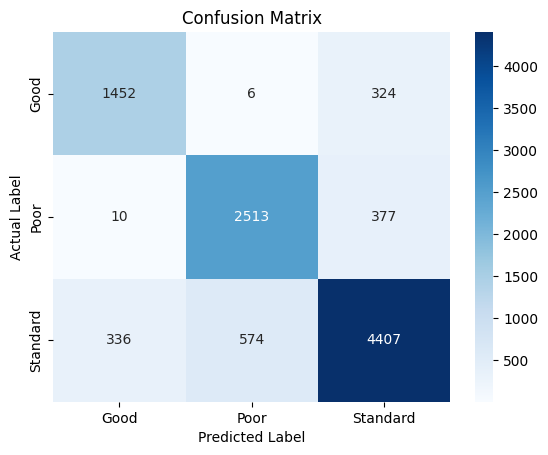

In [ ]:
# Create labels for the confusion matrix
labels = ['Good', 'Poor', 'Standard']

# Create a heatmap using seaborn
sns.heatmap(np.round(confusion_matrices / 10).astype(np.int64), annot=True, cmap='Blues', fmt='d', xticklabels=labels, yticklabels=labels)

# Set plot title and axes labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Display the plot
plt.show()

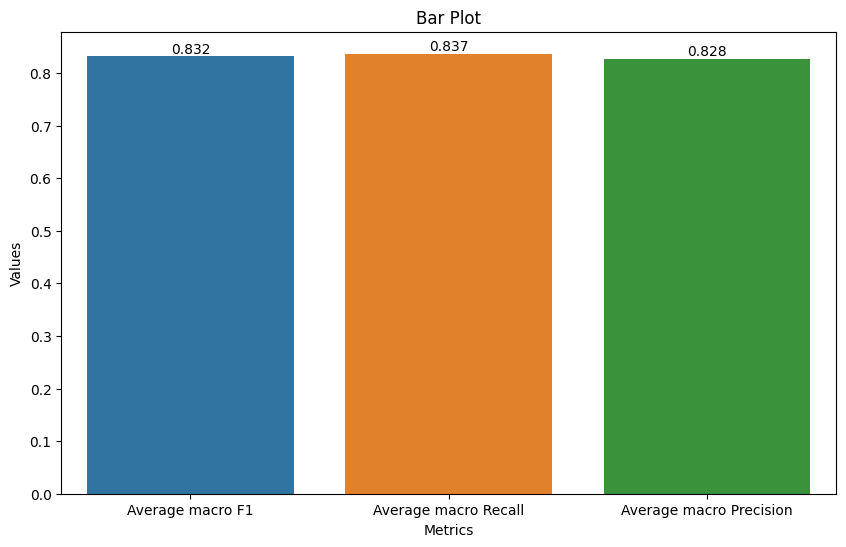

In [ ]:
# Sample data
categories = ['Average macro F1', 'Average macro Recall', 'Average macro Precision']
values = [np.mean(f1_macro), np.mean(recall_macro), np.mean(precision_macro)]

# Set the figure size
plt.figure(figsize=(10, 6))

# Create bar plot
sns.barplot(x=categories, y=values)

# Add numbers on top of the bars
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 3)), ha='center', va='bottom')

# Set plot title and axes labels
plt.title('Bar Plot')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Display the plot
plt.show()


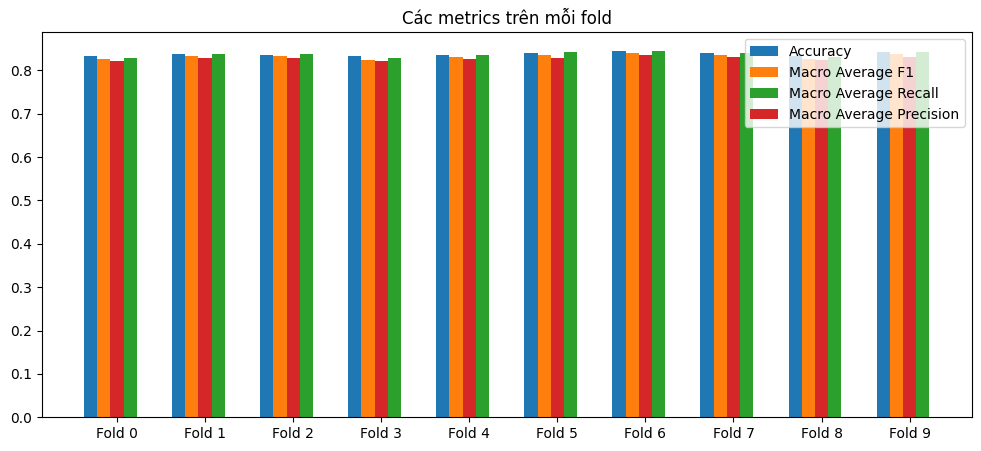

In [ ]:
plt.figure(figsize=(12,5))
X_ticks = ["Fold " + str(i) for i in range(10)]
X_axis = np.arange(len(X_ticks))
plt.bar(X_axis - 0.3, acc, 0.15, label="Accuracy", tick_label=X_ticks)
plt.bar(X_axis - 0.15, f1_macro, 0.15, label="Macro Average F1", tick_label=X_ticks)
plt.bar(X_axis + 0.15, recall_macro, 0.15, label="Macro Average Recall", tick_label=X_ticks)
plt.bar(X_axis, precision_macro, 0.15, label="Macro Average Precision", tick_label=X_ticks)
plt.title("Các metrics trên mỗi fold")
plt.legend()
plt.show()

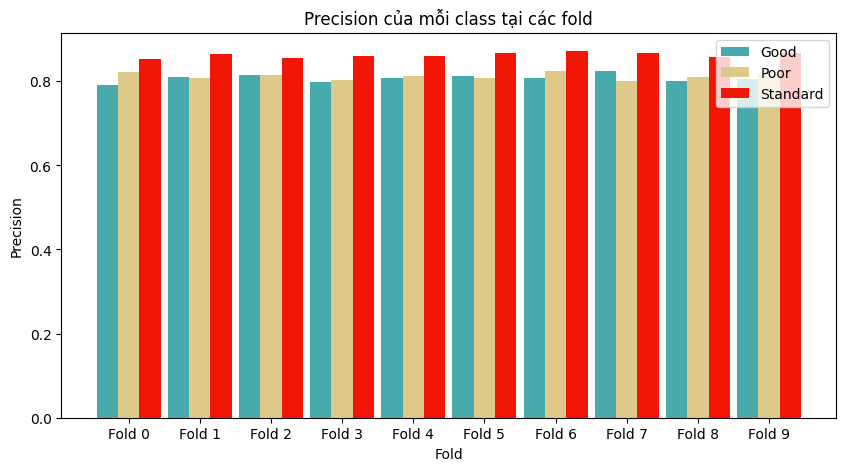

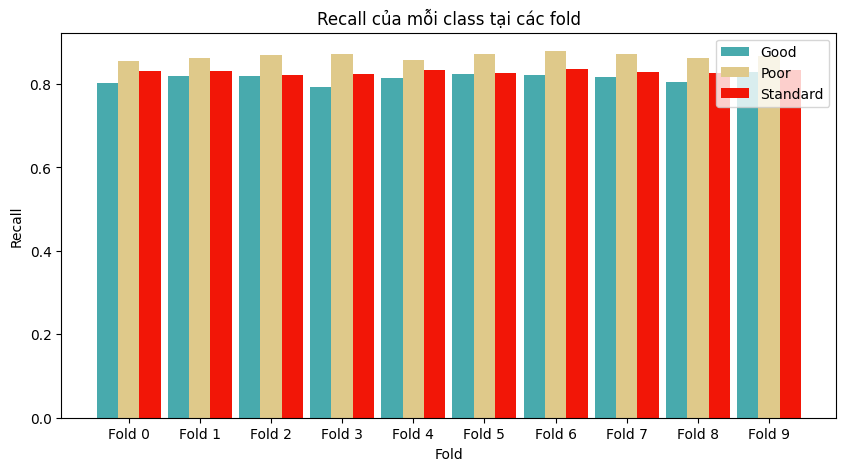

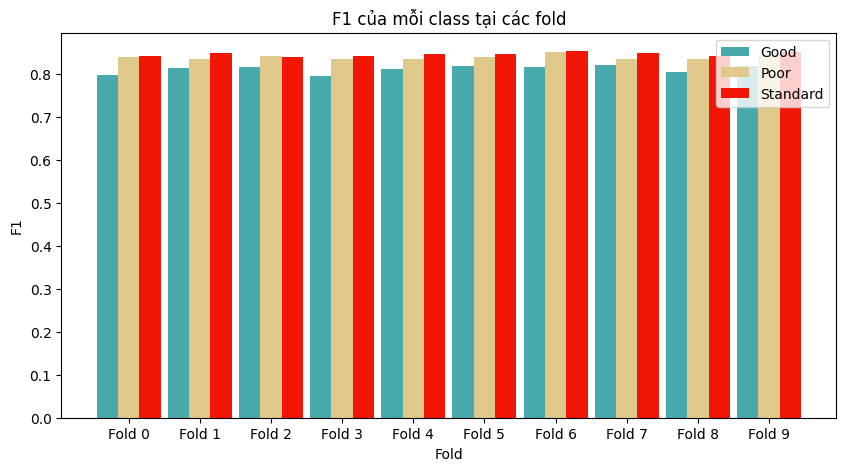

In [ ]:
metrics_dict = {
    "Precision": [],
    "Recall" : [],
    "F1": []
}

for i in range(10):
  metrics_dict["Precision"].append(metrics[i][0])
  metrics_dict["Recall"].append(metrics[i][1])
  metrics_dict["F1"].append(metrics[i][2])

metrics_dict["Precision"] = np.vstack(metrics_dict["Precision"])
metrics_dict["Recall"] = np.vstack(metrics_dict["Recall"])
metrics_dict["F1"] = np.vstack(metrics_dict["F1"])

for metric, values in metrics_dict.items():
  plt.figure(figsize=(10,5))
  plt.bar(X_axis - 0.2, values[:, 0], 0.3,
          label="Good", color="#48AAAD")
  plt.bar(X_axis + 0.1, values[:, 1], 0.3,
          label="Poor", tick_label=X_ticks, color="#DFC98A")
  plt.bar(X_axis + 0.4, values[:, 2], 0.3,
          label="Standard", color="#f21607")

  plt.title(f"{metric} của mỗi class tại các fold")
  plt.xlabel("Fold")
  plt.ylabel(f"{metric}")

  plt.legend()
  plt.show()